In [ ]:
pip install fredapi pandas matplotlib seaborn statsmodels

In [ ]:
API_KEY = "5c383e39cd4a8fbe7e214ebf17f156fc"

In [ ]:
import pandas as pd
from fredapi import Fred
import matplotlib.pyplot as plt
import seaborn as sns

# Connect to FRED
fred = Fred(api_key=API_KEY)

# Pull the three indicators
# We'll go back to 1990 — long enough to see recessions and recoveries
gdp        = fred.get_series('GDP',      observation_start='1990-01-01')
cpi        = fred.get_series('CPIAUCSL', observation_start='1990-01-01')
unemploy   = fred.get_series('UNRATE',   observation_start='1990-01-01')

print("GDP data points:",        len(gdp))
print("CPI data points:",        len(cpi))
print("Unemployment data points:", len(unemploy))




GDP data points: 144
CPI data points: 433
Unemployment data points: 433


In [ ]:
# CPI is a price INDEX (e.g. 300.5) — not very interpretable on its own
# We convert it to Year-over-Year % change = inflation rate
inflation = cpi.pct_change(12) * 100  # 12 months = 1 year

# Quick sanity check — print the last 5 values
print("Inflation rate (last 5 readings):")
print(inflation.tail())

Inflation rate (last 5 readings):
2025-09-01    3.022572
2025-10-01    2.729136
2025-11-01    2.696444
2025-12-01    2.653304
2026-01-01    2.391201
dtype: float64


/tmp/ipykernel_308/3097936405.py:3: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  inflation = cpi.pct_change(12) * 100  # 12 months = 1 year


In [ ]:
# Resample GDP to monthly frequency by forward-filling
# (a quarter's GDP value applies to all 3 months in that quarter)
gdp_monthly = gdp.resample('MS').ffill()

# Combine everything into one DataFrame
df = pd.DataFrame({
    'GDP':        gdp_monthly,
    'Inflation':  inflation,
    'Unemployment': unemploy
})

# Drop rows with missing values (early rows lose data from pct_change calculation)
df.dropna(inplace=True)

# Check your work
print(df.shape)
print(df.tail(10))

(417, 3)
                  GDP  Inflation  Unemployment
2024-12-01  29825.182   2.870691           4.1
2025-01-01  30042.113   2.990978           4.0
2025-02-01  30042.113   2.801583           4.2
2025-03-01  30042.113   2.381981           4.2
2025-04-01  30485.729   2.325388           4.2
2025-05-01  30485.729   2.377265           4.3
2025-06-01  30485.729   2.680454           4.1
2025-07-01  31098.027   2.742618           4.3
2025-08-01  31098.027   2.938592           4.3
2025-09-01  31098.027   3.022572           4.4


In [ ]:
# Correlation matrix — values range from -1 to +1
# -1 = perfect inverse relationship
#  0 = no relationship
# +1 = perfect positive relationship

corr = df.corr()
print("Correlation Matrix:")
print(corr.round(2))

Correlation Matrix:
               GDP  Inflation  Unemployment
GDP           1.00       0.15         -0.27
Inflation     0.15       1.00         -0.34
Unemployment -0.27      -0.34          1.00


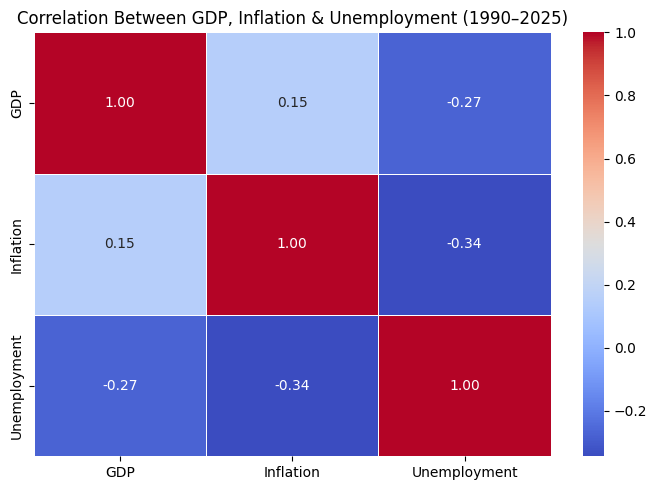

In [ ]:
plt.figure(figsize=(7, 5))
sns.heatmap(
    corr,
    annot=True,          # Show numbers in each cell
    cmap='coolwarm',     # Red = positive, Blue = negative
    fmt='.2f',
    linewidths=0.5
)
plt.title('Correlation Between GDP, Inflation & Unemployment (1990–2025)')
plt.tight_layout()
plt.show()

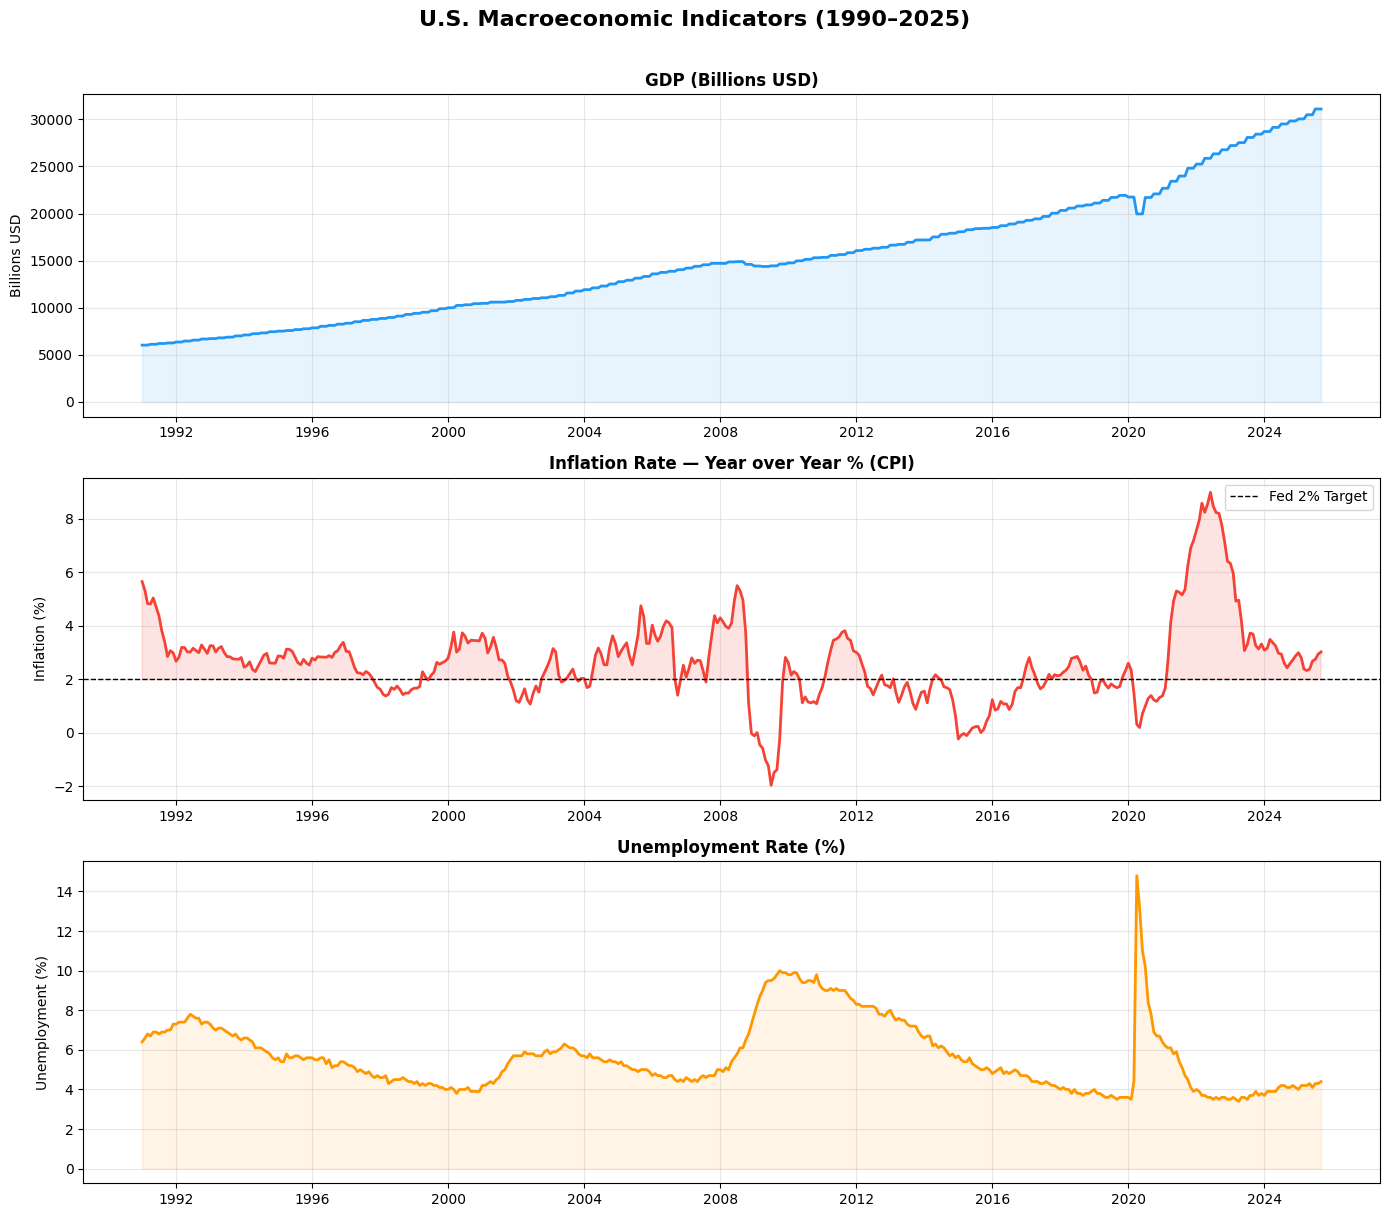

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12))
fig.suptitle('U.S. Macroeconomic Indicators (1990–2025)',
             fontsize=16, fontweight='bold', y=1.01)

# Color scheme
colors = {'GDP': '#2196F3', 'Inflation': '#F44336', 'Unemployment': '#FF9800'}

# --- Plot 1: GDP over time ---
axes[0].plot(df.index, df['GDP'], color=colors['GDP'], linewidth=2)
axes[0].set_title('GDP (Billions USD)', fontweight='bold')
axes[0].set_ylabel('Billions USD')
axes[0].fill_between(df.index, df['GDP'], alpha=0.1, color=colors['GDP'])

# --- Plot 2: Inflation over time ---
axes[1].plot(df.index, df['Inflation'], color=colors['Inflation'], linewidth=2)
axes[1].axhline(y=2, color='black', linestyle='--', linewidth=1, label="Fed 2% Target")
axes[1].set_title('Inflation Rate — Year over Year % (CPI)', fontweight='bold')
axes[1].set_ylabel('Inflation (%)')
axes[1].legend()
axes[1].fill_between(df.index, df['Inflation'], 2,
                      where=(df['Inflation'] > 2),
                      alpha=0.15, color=colors['Inflation'],
                      label='Above target')

# --- Plot 3: Unemployment over time ---
axes[2].plot(df.index, df['Unemployment'], color=colors['Unemployment'], linewidth=2)
axes[2].set_title('Unemployment Rate (%)', fontweight='bold')
axes[2].set_ylabel('Unemployment (%)')
axes[2].fill_between(df.index, df['Unemployment'], alpha=0.1,
                      color=colors['Unemployment'])

for ax in axes:
    ax.grid(True, alpha=0.3)
    ax.set_xlabel('')

plt.tight_layout()
plt.show()

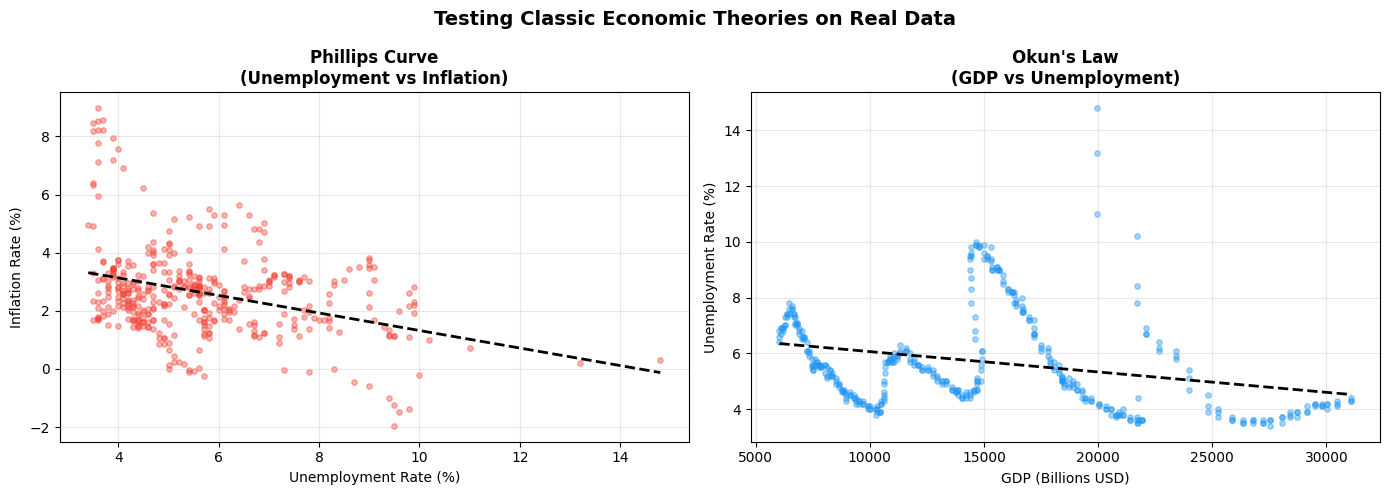

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Testing Classic Economic Theories on Real Data',
             fontsize=14, fontweight='bold')

# --- Phillips Curve ---
axes[0].scatter(df['Unemployment'], df['Inflation'],
                alpha=0.4, color='#F44336', s=15)
# Add trend line
import numpy as np
z = np.polyfit(df['Unemployment'], df['Inflation'], 1)
p = np.poly1d(z)
x_line = np.linspace(df['Unemployment'].min(), df['Unemployment'].max(), 100)
axes[0].plot(x_line, p(x_line), color='black', linewidth=2, linestyle='--')
axes[0].set_title("Phillips Curve\n(Unemployment vs Inflation)", fontweight='bold')
axes[0].set_xlabel('Unemployment Rate (%)')
axes[0].set_ylabel('Inflation Rate (%)')
axes[0].grid(True, alpha=0.3)

# --- Okun's Law ---
axes[1].scatter(df['GDP'], df['Unemployment'],
                alpha=0.4, color='#2196F3', s=15)
z2 = np.polyfit(df['GDP'], df['Unemployment'], 1)
p2 = np.poly1d(z2)
x_line2 = np.linspace(df['GDP'].min(), df['GDP'].max(), 100)
axes[1].plot(x_line2, p2(x_line2), color='black', linewidth=2, linestyle='--')
axes[1].set_title("Okun's Law\n(GDP vs Unemployment)", fontweight='bold')
axes[1].set_xlabel('GDP (Billions USD)')
axes[1].set_ylabel('Unemployment Rate (%)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()